# Logistic Regression on Vehicle Coupon Recommendation Dataset

This notebook performs Exploratory Data Analysis (EDA), Data Preprocessing, and Logistic Regression modeling on the Vehicle Coupon Recommendation dataset. We will focus on visualizing the data to understand underlying patterns.

In [ ]:
# Define Preprocessing Pipeline

# Numeric: Median Imputation -> Standardization
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical: Constant 'missing' Imputation -> OneHotEncoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

## 1. Data Loading and Overview

In [2]:
# Load the dataset
try:
    df = pd.read_csv('../in-vehicle-coupon-recommendation.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Dataset not found! Please check the path.")

# Display first few rows
df.head()

Dataset loaded successfully.


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

## 2. Exploratory Data Analysis (EDA)

### Missing Values

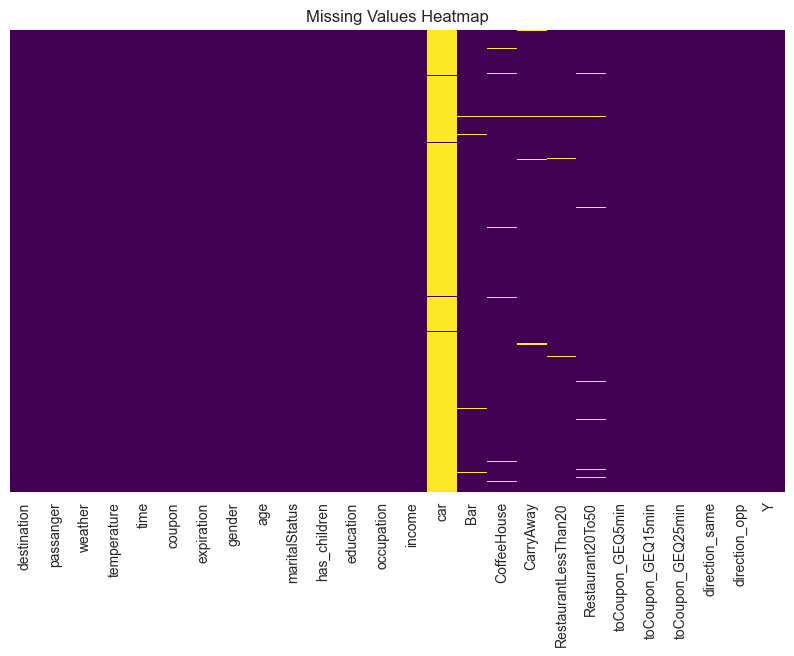

Missing Values Percentage:
car                     99.148534
CoffeeHouse              1.710817
Restaurant20To50         1.490066
CarryAway                1.190476
RestaurantLessThan20     1.024913
Bar                      0.843582
dtype: float64


In [4]:
# Visualize missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()

# Percentage of missing values
missing_percent = df.isnull().mean() * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
print("Missing Values Percentage:")
print(missing_percent)

### Target Distribution (Coupon Acceptance)

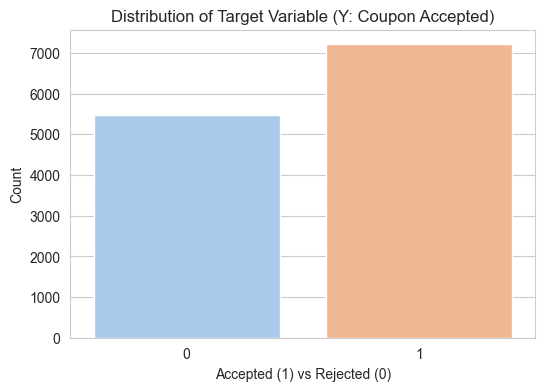

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Y', data=df, palette='pastel')
plt.title('Distribution of Target Variable (Y: Coupon Accepted)')
plt.xlabel('Accepted (1) vs Rejected (0)')
plt.ylabel('Count')
plt.show()

### Coupon Acceptance by Key Categories

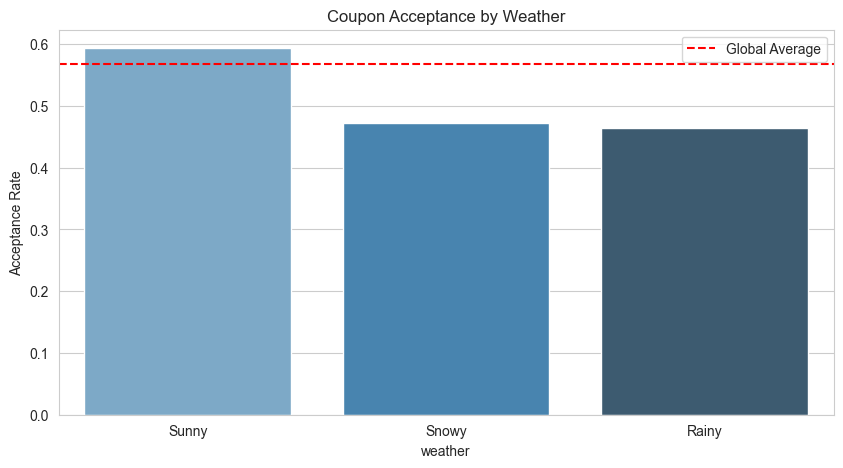

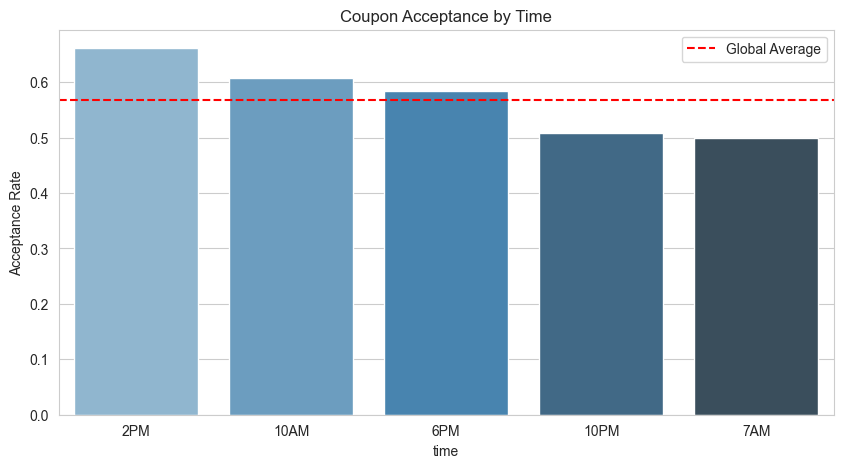

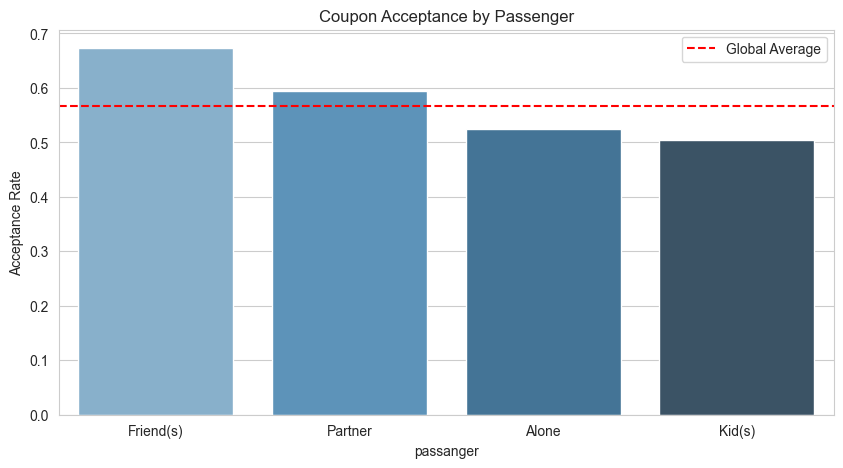

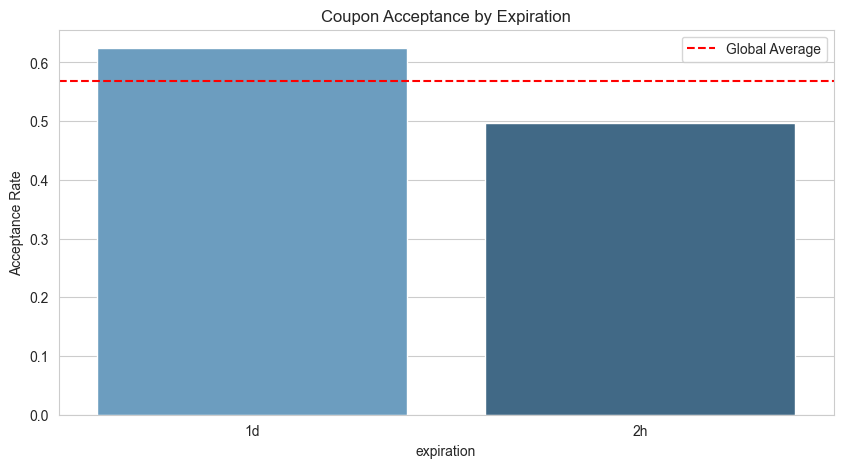

In [21]:
def plot_acceptance_rate(column, title, rotation=0):
    plt.figure(figsize=(10, 5))
    # Calculate acceptance rate
    acceptance_rate = df.groupby(column)['Y'].mean().sort_values(ascending=False).reset_index()
    
    sns.barplot(x=column, y='Y', data=acceptance_rate, palette='Blues_d')
    plt.title(title)
    plt.ylabel('Acceptance Rate')
    plt.xlabel(column)
    plt.xticks(rotation=rotation)
    # Add horizontal line for global average
    plt.axhline(y=df['Y'].mean(), color='r', linestyle='--', label='Global Average')
    plt.legend()
    plt.show()

# Plot acceptance rates for interesting features
plot_acceptance_rate('weather', 'Coupon Acceptance by Weather')
plot_acceptance_rate('time', 'Coupon Acceptance by Time')
plot_acceptance_rate('passanger', 'Coupon Acceptance by Passenger')
plot_acceptance_rate('expiration', 'Coupon Acceptance by Expiration')

*Note: If 'add_coupon' plots fail, it means I need to verify the exact column name 'coupon'.*

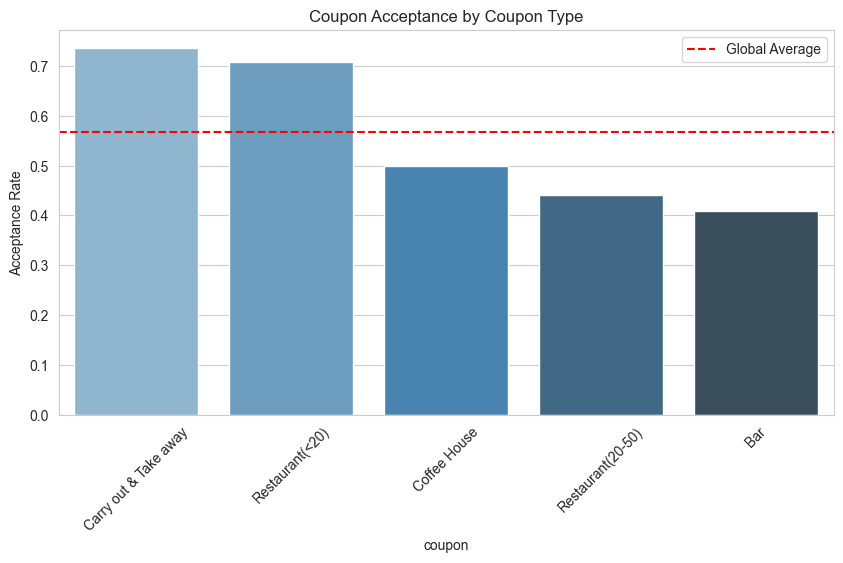

In [8]:
# Correcting column name based on dataset inspection (likely just 'coupon')
if 'coupon' in df.columns:
    plot_acceptance_rate('coupon', 'Coupon Acceptance by Coupon Type', rotation=45)

### Age Distribution and Acceptance

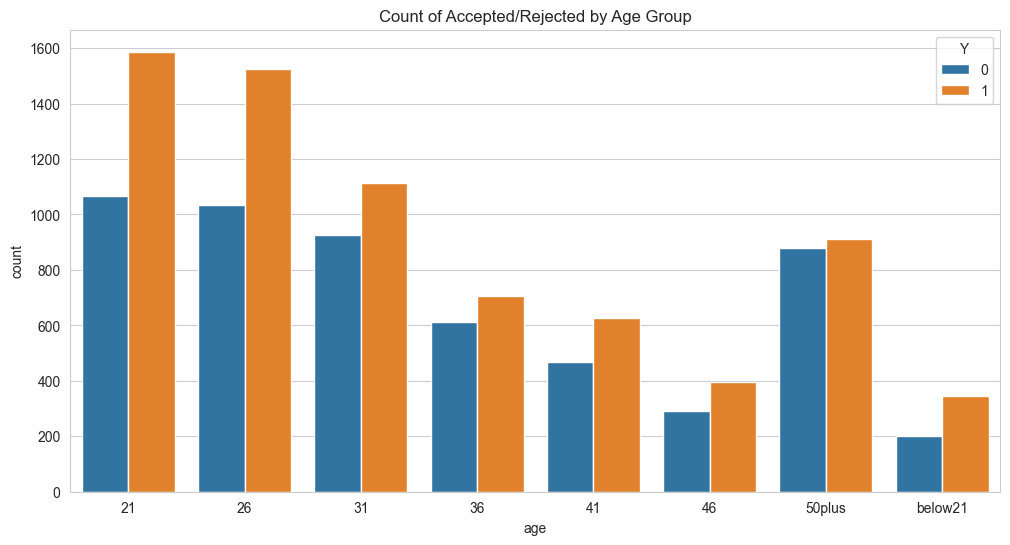

In [9]:
plt.figure(figsize=(12, 6))
sns.countplot(x='age', hue='Y', data=df, order=sorted(df['age'].dropna().unique()))
plt.title('Count of Accepted/Rejected by Age Group')
plt.show()

## 3. Data Preprocessing

We will build a pipeline to:
1. Drop duplicates.
2. Impute missing values.
3. Encode categorical variables.
4. Scale numerical features.

In [ ]:
# Drop duplicates
df = df.drop_duplicates()

# Drop 'car' column if >90% null
if 'car' in df.columns and df['car'].isnull().mean() > 0.9:
    print("Dropping 'car' column due to >90% missing values.")
    df = df.drop(columns=['car'])

# --- Ordinal Encoding for ordered categorical columns ---
FREQUENCY_ORDER = ['never', 'less1', '1~3', '4~8', 'gt8']
AGE_ORDER = ['below21', '21', '26', '31', '36', '41', '46', '50plus']
INCOME_ORDER = [
    'Less than $12500', '$12500 - $24999', '$25000 - $37499',
    '$37500 - $49999', '$50000 - $62499', '$62500 - $74999',
    '$75000 - $87499', '$87500 - $99999', '$100000 or More'
]
EXPIRATION_ORDER = ['2h', '1d']
TIME_MAP = {'7AM': 7, '10AM': 10, '2PM': 14, '6PM': 18, '10PM': 22}
FREQUENCY_COLS = ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']

# Map frequency columns to numeric
freq_map = {v: i for i, v in enumerate(FREQUENCY_ORDER)}
for col in FREQUENCY_COLS:
    if col in df.columns:
        df[col] = df[col].map(freq_map)

# Map age to numeric
age_map = {v: i for i, v in enumerate(AGE_ORDER)}
if 'age' in df.columns:
    df['age'] = df['age'].map(age_map)

# Map income to numeric
income_map = {v: i for i, v in enumerate(INCOME_ORDER)}
if 'income' in df.columns:
    df['income'] = df['income'].map(income_map)

# Map expiration to numeric
exp_map = {v: i for i, v in enumerate(EXPIRATION_ORDER)}
if 'expiration' in df.columns:
    df['expiration'] = df['expiration'].map(exp_map)

# Map time to numeric hour
if 'time' in df.columns:
    df['time'] = df['time'].map(TIME_MAP)

# --- Feature Engineering ---
freq_available = [c for c in FREQUENCY_COLS if c in df.columns]
if freq_available:
    df['total_visits'] = df[freq_available].sum(axis=1)
    print(f"Added 'total_visits' feature (sum of {freq_available})")

if 'passanger' in df.columns:
    df['is_alone'] = (df['passanger'] == 'Alone').astype(int)
    print("Added 'is_alone' feature")

# Separate Target and Features
X = df.drop(columns=['Y'])
y = df['Y']

# Identify Numerical and Categorical columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical Features ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical Features ({len(categorical_cols)}): {categorical_cols}")

In [11]:
# Define Preprocessing Pipeline

# Numeric: Median Imputation -> Standardization
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical: Frequent Imputation -> OneHotEncoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

## 4. Modeling (Logistic Regression)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Create Model Pipeline with class_weight='balanced'
lr = LogisticRegression(max_iter=5000, random_state=42, class_weight='balanced')
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', lr)
])

# Hyperparameter grid for RandomizedSearchCV
param_distributions = {
    'classifier__C': [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100],
    'classifier__solver': ['lbfgs', 'liblinear', 'saga'],
}

# RandomizedSearchCV: 30 iterations, 5-fold CV, f1_weighted scoring
search = RandomizedSearchCV(
    clf,
    param_distributions=param_distributions,
    n_iter=30,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)

print(f"Best Parameters: {search.best_params_}")
print(f"Best CV Score (f1_weighted): {search.best_score_:.4f}")

# Use best estimator for predictions
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Model Trained Successfully!")

import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer


## 5. Evaluation

In [19]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.6840

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.57      0.61      1106
           1       0.70      0.77      0.73      1416

    accuracy                           0.68      2522
   macro avg       0.68      0.67      0.67      2522
weighted avg       0.68      0.68      0.68      2522



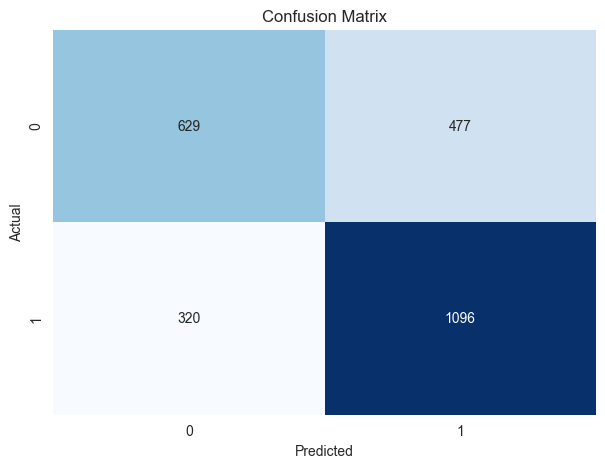

In [14]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### ROC Curve

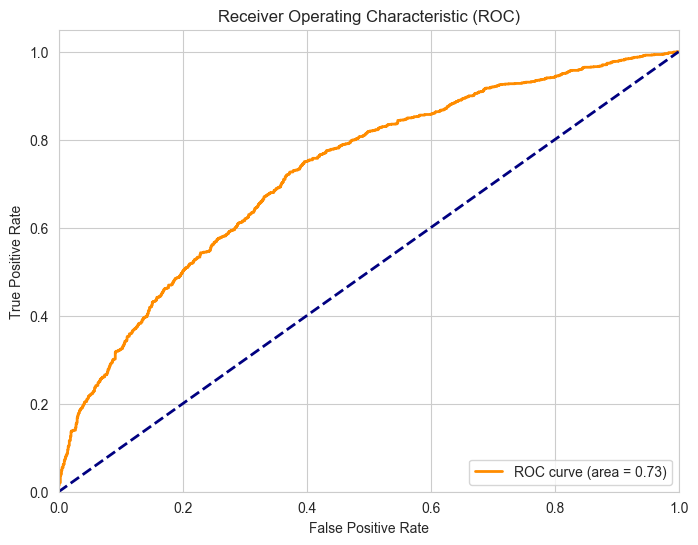

In [22]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

### Feature Importance (Top Coefficients)

This helps us understand which features drive the decision to accept a coupon.

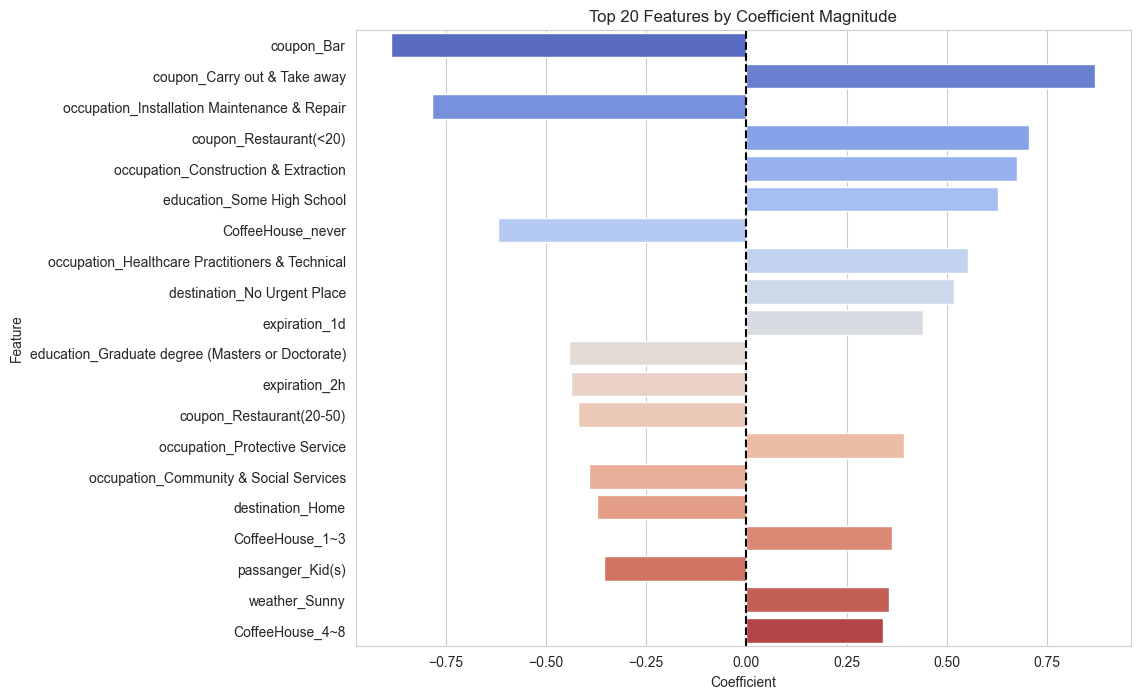

In [17]:
# Extract features names after one-hot encoding
# Access the steps
model = clf.named_steps['classifier']
transformer = clf.named_steps['preprocessor']

# Get feature names
try:
    # Numerical names
    num_names = numerical_cols
    # Categorical names
    cat_names = transformer.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_cols)
    
    feature_names = np.r_[num_names, cat_names]
    
    # Get coefficients
    coefs = model.coef_[0]
    
    # Create DataFrame
    coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefs})
    coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
    coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(20)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='coolwarm')
    plt.title('Top 20 Features by Coefficient Magnitude')
    plt.axvline(x=0, color='black', linestyle='--')
    plt.show()
except Exception as e:
    print(f"Could not extract feature names directly: {e}")